In [3]:
# Load Data + Train Best Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("../data/raw/creditcard.csv")

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


ROC-AUC Score: 0.9731567729089385


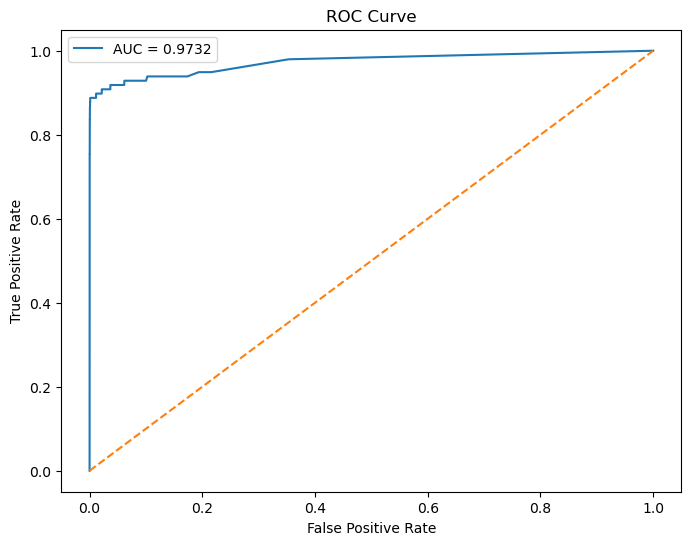

In [4]:
# ROC Curve + AUC Score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = rf.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

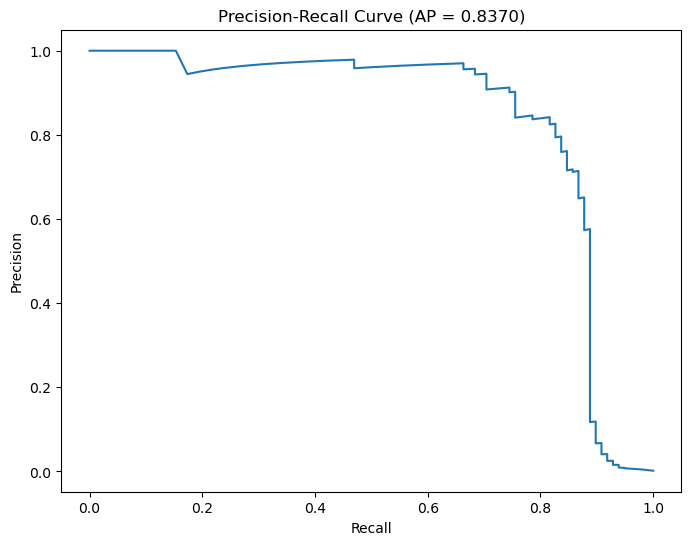

In [5]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresh = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap:.4f})")
plt.show()

In [6]:
# Find Best Threshold for Fraud Detection
import numpy as np
from sklearn.metrics import f1_score

best_thresh = 0
best_f1 = 0

for t in np.arange(0.01, 0.50, 0.01):
    preds = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("BEST THRESHOLD:", best_thresh)
print("BEST F1 SCORE:", best_f1)

BEST THRESHOLD: 0.46
BEST F1 SCORE: 0.8290155440414507


In [7]:
# Evaluate Model with Best Threshold
from sklearn.metrics import classification_report, confusion_matrix

final_preds = (y_pred_proba >= best_thresh).astype(int)

print("Classification Report:")
print(classification_report(y_test, final_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_preds))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56849    15]
 [   18    80]]


In [8]:
# Compare 0.50 vs Best Threshold
preds_default = (y_pred_proba >= 0.5).astype(int)

from sklearn.metrics import f1_score, recall_score, precision_score

print("Default Threshold 0.50:")
print("F1:", f1_score(y_test, preds_default))
print("Recall:", recall_score(y_test, preds_default))
print("Precision:", precision_score(y_test, preds_default))

print("\nOptimized Threshold", best_thresh)
print("F1:", f1_score(y_test, final_preds))
print("Recall:", recall_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds))

Default Threshold 0.50:
F1: 0.8105263157894737
Recall: 0.7857142857142857
Precision: 0.8369565217391305

Optimized Threshold 0.46
F1: 0.8290155440414507
Recall: 0.8163265306122449
Precision: 0.8421052631578947


In [9]:
# Save the Final Optimized Model
import joblib

joblib.dump(rf, "models/final_fraud_model.pkl")

best_threshold = 0.5

with open("models/best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Model + Threshold Saved Successfully!")

Model + Threshold Saved Successfully!


In [10]:
import joblib

feature_order = x_train.columns.tolist()

joblib.dump(feature_order, "../streamlit_app/feature_order.pkl")

print("Feature order saved")

Feature order saved
